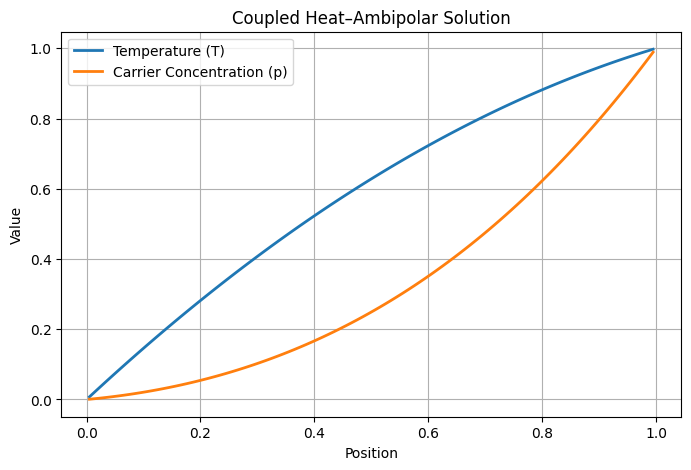

In [1]:
from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# Domain
L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)

# Time
dt = 1e-3
final_time = 1.0
steps = int(final_time / dt)

# Heat equation parameters
alpha = 1.0          # Thermal diffusivity
heat_source = 1.0    # JE/(rho*Cp)

# Ambipolar parameters
D = 1.0              # Diffusion coefficient
v = 1.0              # Drift velocity
Sp = 1.0             # Coupling coefficient

T = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=0.0,
    hasOld=True
)

p = CellVariable(
    name="Carrier Concentration",
    mesh=mesh,
    value=0.0,
    hasOld=True
)

x = mesh.cellCenters[0]

T.setValue(np.sin(np.pi * x / L))
p.setValue(np.sin(np.pi * x / L))

# Heat
T.constrain(0.0, mesh.facesLeft)
T.constrain(1.0, mesh.facesRight)

# Ambipolar
p.constrain(0.0, mesh.facesLeft)
p.constrain(1.0, mesh.facesRight)

heatEq = (
    TransientTerm()
    == DiffusionTerm(coeff=alpha)
    + heat_source
)

amb_source = CellVariable(
    mesh=mesh,
    value=0.0
)

ambEq = (
    TransientTerm()
    == DiffusionTerm(coeff=D)
    - PowerLawConvectionTerm(coeff=(v,))
    + amb_source
)

# Store solutions for plotting
T_history = []
p_history = []
time_history = []

for step in range(steps):

    # Update old values
    T.updateOld()
    p.updateOld()

    heatEq.solve(var=T, dt=dt)

    lapT = T.faceGrad.divergence # Compute ∇²T

    amb_source.setValue(D * Sp * lapT.value) # Update Ambipolar Source

    ambEq.solve(var=p, dt=dt)

    # Store results every 100 steps
    if step % 100 == 0:
        T_history.append(T.value.copy())
        p_history.append(p.value.copy())
        time_history.append((step + 1) * dt)

x = mesh.cellCenters[0].value

plt.figure(figsize=(8,5))

plt.plot(x, T.value, label='Temperature (T)', linewidth=2)
plt.plot(x, p.value, label='Carrier Concentration (p)', linewidth=2)

plt.xlabel('Position')
plt.ylabel('Value')
plt.title('Coupled Heat–Ambipolar Solution')
plt.grid(True)
plt.legend()

plt.show()


Temperature:
[0.00754939 0.02254812 0.0374467  0.05224504 0.06694303 0.08154059
 0.09603762 0.11043402 0.12472969 0.13892455 0.15301849 0.16701142
 0.18090326 0.19469392 0.20838329 0.2219713  0.23545786 0.24884288
 0.26212628 0.27530798 0.28838789 0.30136594 0.31424204 0.32701614
 0.33968814 0.35225799 0.3647256  0.37709092 0.38935389 0.40151443
 0.41357248 0.425528   0.43738093 0.44913121 0.4607788  0.47232364
 0.48376569 0.49510492 0.50634128 0.51747474 0.52850526 0.53943282
 0.55025739 0.56097893 0.57159744 0.58211289 0.59252527 0.60283456
 0.61304077 0.62314387 0.63314387 0.64304076 0.65283456 0.66252526
 0.67211288 0.68159743 0.69097892 0.70025737 0.70943281 0.71850525
 0.72747473 0.73634127 0.7451049  0.75376567 0.76232362 0.77077877
 0.77913119 0.78738091 0.79552798 0.80357246 0.8115144  0.81935386
 0.8270909  0.83472558 0.84225796 0.84968811 0.85701611 0.86424202
 0.87136591 0.87838786 0.88530795 0.89212626 0.89884286 0.90545784
 0.91197128 0.91838327 0.9246939  0.93090324 0.9

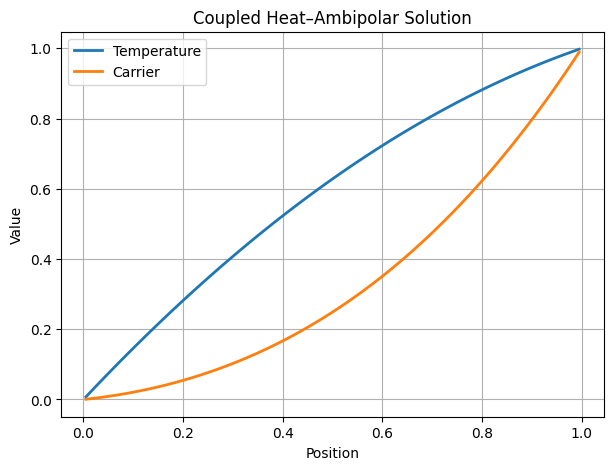

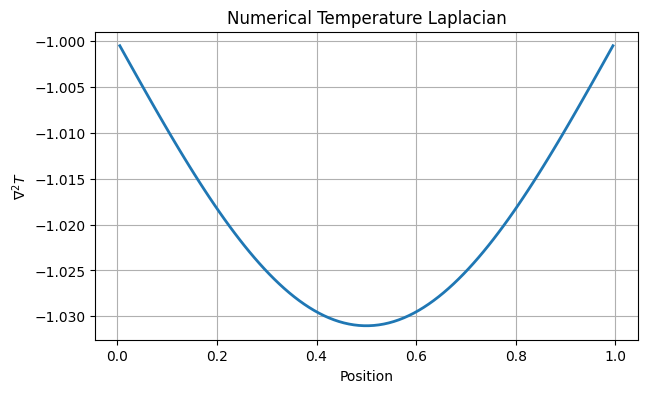

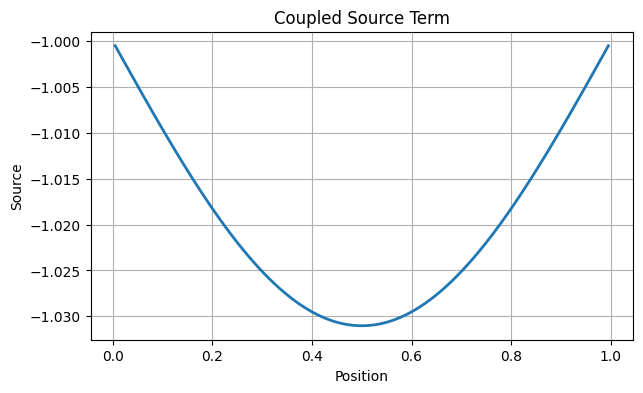

In [ ]:
from fipy import *
import numpy as np
import matplotlib.pyplot as plt

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x = mesh.cellCenters[0].value

dt = 1e-3
final_time = 1.0
steps = int(final_time / dt)

# HEAT PARAMETERS
alpha = 1.0
heat_source = 1.0

# AMBIPOLAR PARAMETERS
D = 1.0
v = 1.0
Sp = 1.0

T = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x / L),
    hasOld=True
)

p = CellVariable(
    name="Carrier",
    mesh=mesh,
    value=np.sin(np.pi * x / L),
    hasOld=True
)

# BOUNDARY CONDITIONS
T.constrain(0.0, mesh.facesLeft)
T.constrain(1.0, mesh.facesRight)

p.constrain(0.0, mesh.facesLeft)
p.constrain(1.0, mesh.facesRight)

amb_source = CellVariable(mesh=mesh, value=0.0)

heatEq = (
    TransientTerm()
    == DiffusionTerm(coeff=alpha)
    + heat_source
)

ambEq = (
    TransientTerm()
    == DiffusionTerm(coeff=D)
    - PowerLawConvectionTerm(coeff=(v,))
    + amb_source
)

for step in range(steps):

    T.updateOld()
    p.updateOld()

    heatEq.solve(var=T, dt=dt)

    lapT = T.faceGrad.divergence # Numerical Laplacian

    amb_source.setValue(D * Sp * lapT.value) # Update coupled source

    ambEq.solve(var=p, dt=dt)

print("\nTemperature:")
print(T.value)

print("\nLaplacian:")
print(lapT.value)

print("\nCoupled Source:")
print(amb_source.value)

plt.figure(figsize=(7,5))
plt.plot(x, T.value, lw=2, label="Temperature")
plt.plot(x, p.value, lw=2, label="Carrier")
plt.xlabel("Position")
plt.ylabel("Value")
plt.title("Coupled Heat–Ambipolar Solution")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(x, lapT.value, lw=2)
plt.xlabel("Position")
plt.ylabel(r"$\nabla^2 T$")
plt.title("Numerical Temperature Laplacian")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(x, amb_source.value, lw=2)
plt.xlabel("Position")
plt.ylabel("Source")
plt.title("Coupled Source Term")
plt.grid(True)
plt.show()


Temperature:
[0.00754939 0.02254812 0.0374467  0.05224504 0.06694303 0.08154059
 0.09603762 0.11043402 0.12472969 0.13892455 0.15301849 0.16701142
 0.18090326 0.19469392 0.20838329 0.2219713  0.23545786 0.24884288
 0.26212628 0.27530798 0.28838789 0.30136594 0.31424204 0.32701614
 0.33968814 0.35225799 0.3647256  0.37709092 0.38935389 0.40151443
 0.41357248 0.425528   0.43738093 0.44913121 0.4607788  0.47232364
 0.48376569 0.49510492 0.50634128 0.51747474 0.52850526 0.53943282
 0.55025739 0.56097893 0.57159744 0.58211289 0.59252527 0.60283456
 0.61304077 0.62314387 0.63314387 0.64304076 0.65283456 0.66252526
 0.67211288 0.68159743 0.69097892 0.70025737 0.70943281 0.71850525
 0.72747473 0.73634127 0.7451049  0.75376567 0.76232362 0.77077877
 0.77913119 0.78738091 0.79552798 0.80357246 0.8115144  0.81935386
 0.8270909  0.83472558 0.84225796 0.84968811 0.85701611 0.86424202
 0.87136591 0.87838786 0.88530795 0.89212626 0.89884286 0.90545784
 0.91197128 0.91838327 0.9246939  0.93090324 0.9

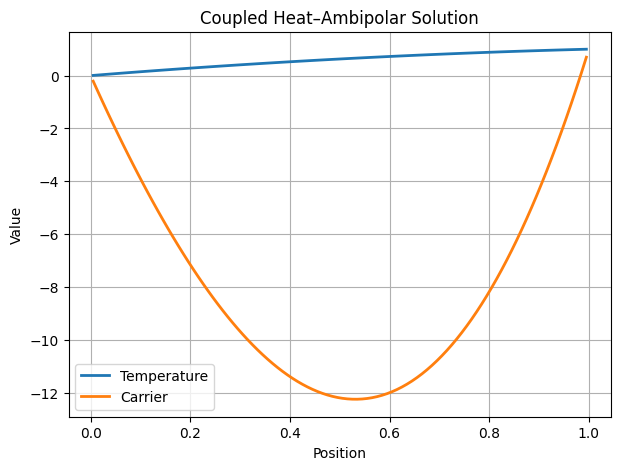

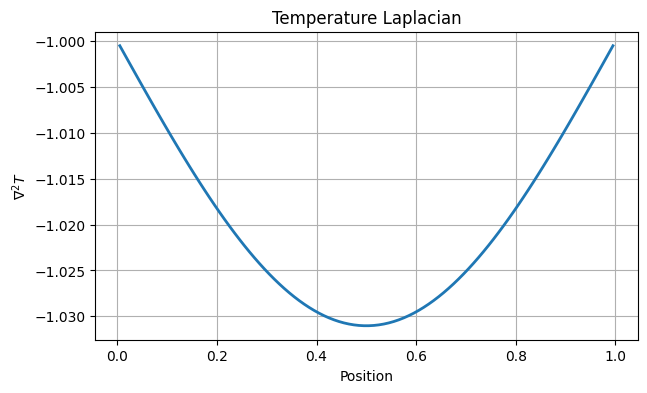

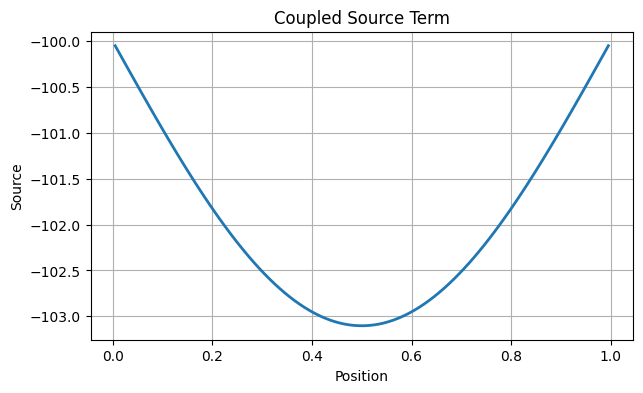

In [ ]:
from fipy import *
import numpy as np
import matplotlib.pyplot as plt

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x = mesh.cellCenters[0].value

dt = 1e-3
final_time = 1.0
steps = int(final_time / dt)

# HEAT PARAMETERS
alpha = 1.0
heat_source = 1.0

# AMBIPOLAR PARAMETERS
D = 1.0
v = 1.0
Sp = 100.0

T = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x / L),
    hasOld=True
)

p = CellVariable(
    name="Carrier",
    mesh=mesh,
    value=np.sin(np.pi * x / L),
    hasOld=True
)

# BOUNDARY CONDITIONS
T.constrain(0.0, mesh.facesLeft)
T.constrain(1.0, mesh.facesRight)

p.constrain(0.0, mesh.facesLeft)
p.constrain(1.0, mesh.facesRight)

heatEq = (
    TransientTerm()
    == DiffusionTerm(coeff=alpha)
    + heat_source
)

ambEq = (
    TransientTerm()
    == DiffusionTerm(coeff=D)
    - PowerLawConvectionTerm(coeff=(v,))
    + (D * Sp * T.faceGrad).divergence
)

# STORAGE

T_history = []
p_history = []

for step in range(steps):

    T.updateOld()
    p.updateOld()

    heatEq.solve(var=T, dt=dt)

    ambEq.solve(var=p, dt=dt)

    if step % 100 == 0:
        T_history.append(T.value.copy())
        p_history.append(p.value.copy())

# COMPUTE SOURCE FOR VISUALIZATION

lapT = T.faceGrad.divergence
coupled_source = (D * Sp * T.faceGrad).divergence

print("\nTemperature:")
print(T.value)

print("\nLaplacian:")
print(lapT.value)

print("\nCoupled Source:")
print(coupled_source.value)


plt.figure(figsize=(7,5))
plt.plot(x, T.value, lw=2, label="Temperature")
plt.plot(x, p.value, lw=2, label="Carrier")
plt.xlabel("Position")
plt.ylabel("Value")
plt.title("Coupled Heat–Ambipolar Solution")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(x, lapT.value, lw=2)
plt.xlabel("Position")
plt.ylabel(r"$\nabla^2T$")
plt.title("Temperature Laplacian")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(x, coupled_source.value, lw=2)
plt.xlabel("Position")
plt.ylabel("Source")
plt.title("Coupled Source Term")
plt.grid(True)
plt.show()


Temperature Field
[33.85632066 34.2339531  34.26648944 34.29776738 34.32893399 34.35996155
 34.39081943 34.42147719 34.45190457 34.48207154 34.51194833 34.54150545
 34.57071375 34.59954438 34.6279689  34.65595927 34.68348784 34.71052746
 34.73705145 34.76303362 34.78844834 34.81327052 34.83747566 34.86103989
 34.88393994 34.90615322 34.9276578  34.94843246 34.9684567  34.98771075
 35.00617562 35.02383309 35.04066572 35.05665691 35.07179087 35.08605267
 35.09942824 35.11190437 35.12346875 35.13410997 35.14381753 35.15258184
 35.16039427 35.16724709 35.17313354 35.17804782 35.18198508 35.18494143
 35.18691395 35.1879007  35.1879007  35.18691395 35.18494143 35.18198508
 35.17804782 35.17313354 35.16724709 35.16039427 35.15258184 35.14381753
 35.13410997 35.12346875 35.11190437 35.09942824 35.08605267 35.07179087
 35.05665691 35.04066572 35.02383309 35.00617562 34.98771075 34.9684567
 34.94843246 34.9276578  34.90615322 34.88393994 34.86103989 34.83747566
 34.81327052 34.78844834 34.76303

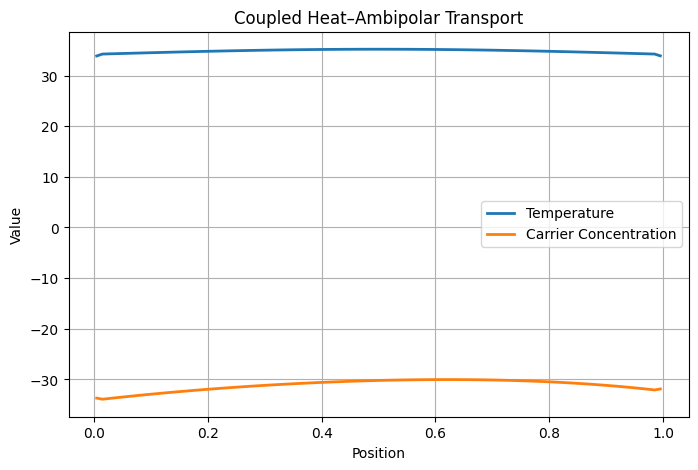

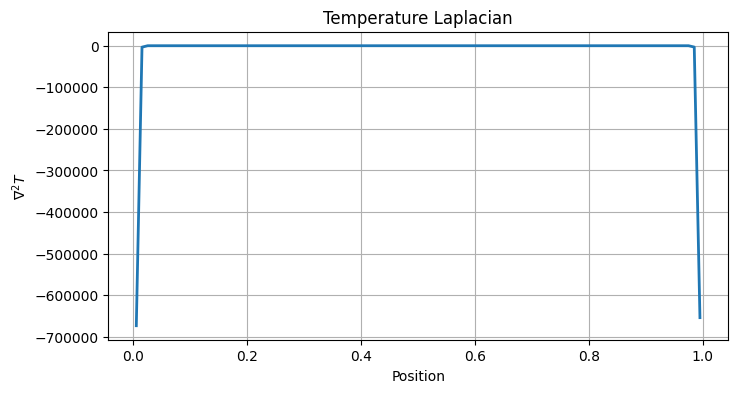

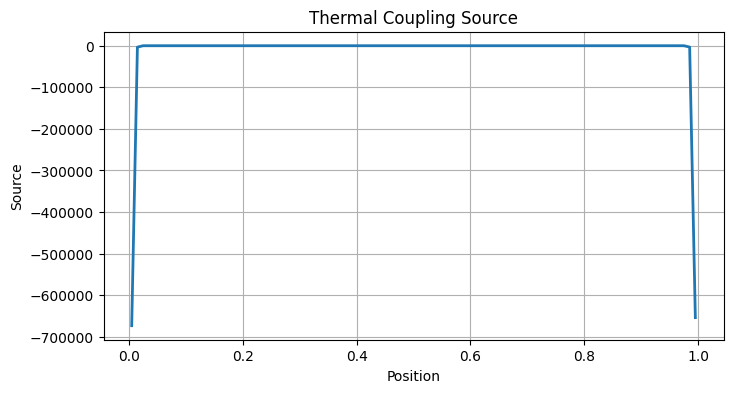

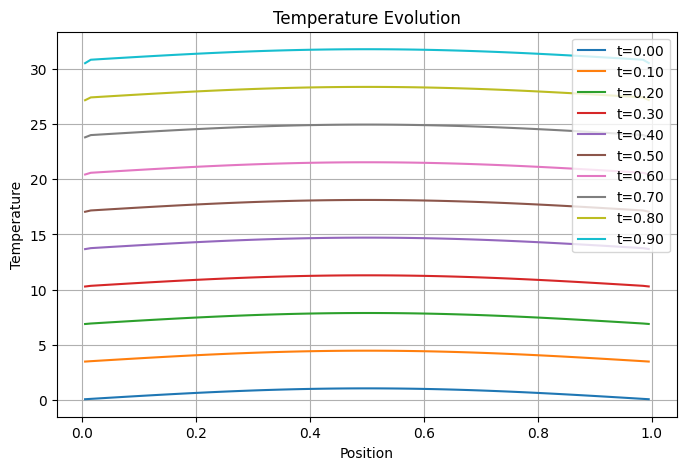

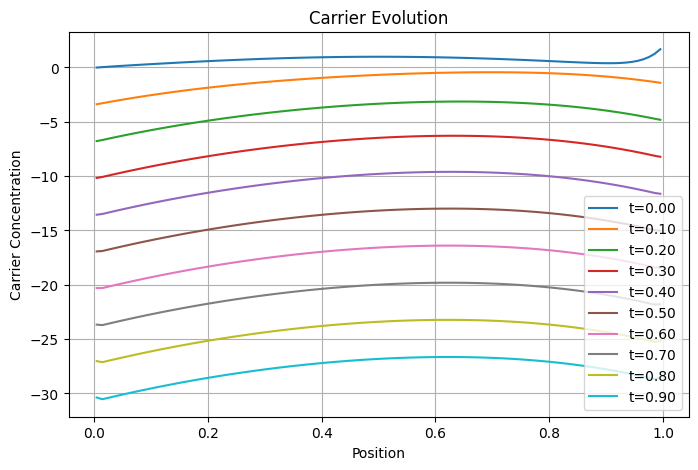

In [ ]:
from fipy import *
import numpy as np
import matplotlib.pyplot as plt

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x = mesh.cellCenters[0].value

dt = 1e-3
final_time = 1.0
steps = int(final_time / dt)

# PHYSICAL PARAMETERS (HEAT)
rho = 6500.0          # Density (kg/m^3)
Cp = 450.0            # Specific Heat (J/kg-K)
k_th = 3.0            # Thermal Conductivity (W/m-K)
Q = 1e8               # Volumetric Heat Generation (W/m^3)

# AMBIPOLAR PARAMETERS
D = 1.0               # Diffusion Coefficient
v = 1.0               # Drift Velocity
Sp = 1.0              # Thermal Coupling Coefficient

T = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x / L),
    hasOld=True
)

p = CellVariable(
    name="Carrier Concentration",
    mesh=mesh,
    value=np.sin(np.pi * x / L),
    hasOld=True
)

# BOUNDARY CONDITIONS
T.constrain(0.0, mesh.facesLeft)
T.constrain(1.0, mesh.facesRight)

p.constrain(0.0, mesh.facesLeft)
p.constrain(1.0, mesh.facesRight)

# HEAT EQUATION :- rho Cp dT/dt = kth ∇²T + Q

heatEq = (
    TransientTerm(coeff=rho * Cp)
    ==
    DiffusionTerm(coeff=k_th)
    + Q
)

# AMBIPOLAR EQUATION :- dp/dt = D∇²p - v∇p + DSp∇²T

ambEq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=D)
    - PowerLawConvectionTerm(coeff=(v,))
    + (D * Sp * T.faceGrad).divergence
)

# STORAGE

T_history = []
p_history = []
time_history = []

for step in range(steps):

    T.updateOld()
    p.updateOld()

    heatEq.solve(var=T, dt=dt)

    ambEq.solve(var=p, dt=dt)

    if step % 100 == 0:
        T_history.append(T.value.copy())
        p_history.append(p.value.copy())
        time_history.append((step + 1) * dt)

# POST-PROCESSING

lapT = T.faceGrad.divergence
coupled_source = (D * Sp * T.faceGrad).divergence

print("\nTemperature Field")
print(T.value)

print("\nTemperature Laplacian")
print(lapT.value)

print("\nCoupled Source")
print(coupled_source.value)

plt.figure(figsize=(8,5))

plt.plot(x, T.value,
         linewidth=2,
         label='Temperature')

plt.plot(x, p.value,
         linewidth=2,
         label='Carrier Concentration')

plt.xlabel("Position")
plt.ylabel("Value")
plt.title("Coupled Heat–Ambipolar Transport")
plt.grid(True)
plt.legend()

plt.show()

# TEMPERATURE LAPLACIAN

plt.figure(figsize=(8,4))

plt.plot(x,
         lapT.value,
         linewidth=2)

plt.xlabel("Position")
plt.ylabel(r"$\nabla^2 T$")
plt.title("Temperature Laplacian")
plt.grid(True)

plt.show()

# COUPLED SOURCE

plt.figure(figsize=(8,4))

plt.plot(x,
         coupled_source.value,
         linewidth=2)

plt.xlabel("Position")
plt.ylabel("Source")
plt.title("Thermal Coupling Source")
plt.grid(True)

plt.show()

# TEMPERATURE EVOLUTION

plt.figure(figsize=(8,5))

for i, sol in enumerate(T_history):
    plt.plot(x, sol, label=f"t={time_history[i]:.2f}")

plt.xlabel("Position")
plt.ylabel("Temperature")
plt.title("Temperature Evolution")
plt.grid(True)
plt.legend()

plt.show()

# CARRIER EVOLUTION

plt.figure(figsize=(8,5))

for i, sol in enumerate(p_history):
    plt.plot(x, sol, label=f"t={time_history[i]:.2f}")

plt.xlabel("Position")
plt.ylabel("Carrier Concentration")
plt.title("Carrier Evolution")
plt.grid(True)
plt.legend()

plt.show()

In [16]:
print(np.min(lapT.value))
print(np.max(lapT.value))

print(np.min(lapT.value[5:-5]))
print(np.max(lapT.value[5:-5]))

-673350.0889342467
-1.1097652988922846
-9.867475321172492
-1.6967155716685056



Coupling Validation
Maximum Difference : 33.91755300273509
L2 Difference      : 31.58871077102758


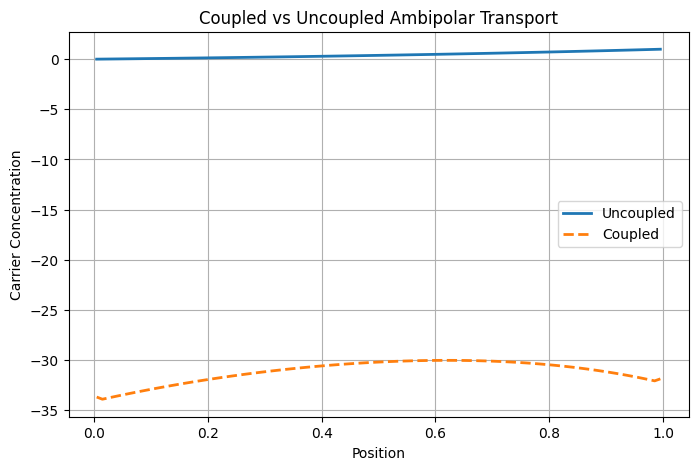

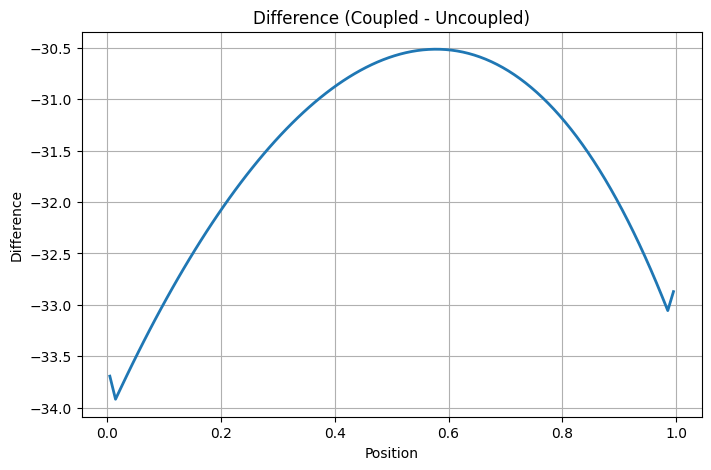

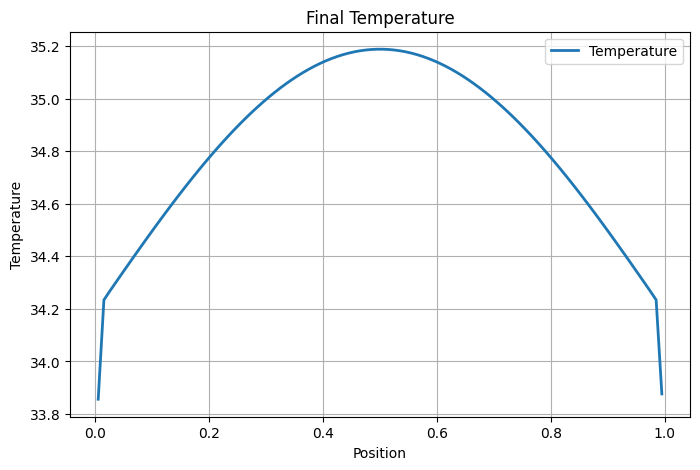

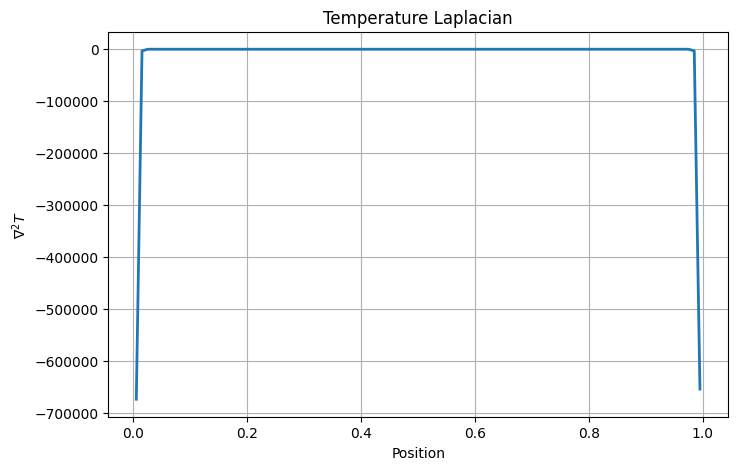

In [ ]:
from fipy import *
import numpy as np
import matplotlib.pyplot as plt

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x = mesh.cellCenters[0].value

dt = 1e-3
final_time = 1.0
steps = int(final_time / dt)

# PHYSICAL PARAMETERS (HEAT)

rho = 6500.0
Cp = 450.0
k_th = 3.0
Q = 1e8

# AMBIPOLAR PARAMETERS

D = 1.0
v = 1.0
Sp = 1.0

T = CellVariable(
    mesh=mesh,
    value=np.sin(np.pi*x/L),
    hasOld=True
)

p_uncoupled = CellVariable(
    mesh=mesh,
    value=np.sin(np.pi*x/L),
    hasOld=True
)

p_coupled = CellVariable(
    mesh=mesh,
    value=np.sin(np.pi*x/L),
    hasOld=True
)

# BOUNDARY CONDITIONS
T.constrain(0.0, mesh.facesLeft)
T.constrain(1.0, mesh.facesRight)

p_uncoupled.constrain(0.0, mesh.facesLeft)
p_uncoupled.constrain(1.0, mesh.facesRight)

p_coupled.constrain(0.0, mesh.facesLeft)
p_coupled.constrain(1.0, mesh.facesRight)

# HEAT EQUATION

heatEq = (
    TransientTerm(coeff=rho*Cp)
    ==
    DiffusionTerm(coeff=k_th)
    + Q
)

for step in range(steps):

    T.updateOld()
    p_uncoupled.updateOld()
    p_coupled.updateOld()

    heatEq.solve(var=T, dt=dt)

    # Uncoupled Ambipolar

    ambEq_uncoupled = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=D)
        - PowerLawConvectionTerm(coeff=(v,))
    )

    ambEq_uncoupled.solve(var=p_uncoupled, dt=dt)

    # Coupled Ambipolar

    coupled_source = (D * Sp * T.faceGrad).divergence

    ambEq_coupled = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=D)
        - PowerLawConvectionTerm(coeff=(v,))
        + coupled_source
    )

    ambEq_coupled.solve(var=p_coupled, dt=dt)

# POST PROCESSING

lapT = T.faceGrad.divergence.value

difference = p_coupled.value - p_uncoupled.value

print("\n==============================")
print("Coupling Validation")
print("==============================")

print("Maximum Difference :", np.max(np.abs(difference)))
print("L2 Difference      :", np.sqrt(np.mean(difference**2)))

plt.figure(figsize=(8,5))

plt.plot(x, p_uncoupled.value,
         linewidth=2,
         label='Uncoupled')

plt.plot(x, p_coupled.value,
         '--',
         linewidth=2,
         label='Coupled')

plt.xlabel("Position")
plt.ylabel("Carrier Concentration")
plt.title("Coupled vs Uncoupled Ambipolar Transport")
plt.grid(True)
plt.legend()

plt.show()

plt.figure(figsize=(8,5))

plt.plot(x, difference,
         linewidth=2)

plt.xlabel("Position")
plt.ylabel("Difference")
plt.title("Difference (Coupled - Uncoupled)")
plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.plot(x, T.value,
         linewidth=2,
         label="Temperature")

plt.xlabel("Position")
plt.ylabel("Temperature")
plt.title("Final Temperature")
plt.grid(True)
plt.legend()

plt.show()

plt.figure(figsize=(8,5))

plt.plot(x, lapT,
         linewidth=2)

plt.xlabel("Position")
plt.ylabel(r"$\nabla^2 T$")
plt.title("Temperature Laplacian")
plt.grid(True)

plt.show()